In [20]:
!pip install mlflow
!pip install python-dotenv
!pip install seaborn
!pip install emoji
!pip install langdetect
!pip install lime
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---

ERROR: Could not install packages due to an OSError: [WinError 32] Le processus ne peut pas accéder au fichier car ce fichier est utilisé par un autre processus: 'C:\\Users\\edoah\\AppData\\Local\\Temp\\pip-unpack-990ds9a_\\xgboost-3.2.0-py3-none-win_amd64.whl'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
import json
import spacy
import re
import emoji
import wget
import time
import mlflow 
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from nltk.stem.snowball import SnowballStemmer
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from langdetect import detect, LangDetectException
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve, get_scorer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv


In [5]:
# Charger les variables d'environnement depuis .env (force reload)
load_dotenv(override=True)

# Vérifier que les variables sont bien chargées
tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
experiment_name = os.getenv("EXPERIMENT_NAME")  # Par défaut = tracking_uri
print(f"MLFLOW_TRACKING_URI: {tracking_uri}")
print(f"EXPERIMENT_NAME: {experiment_name}")

mlflow.set_tracking_uri(tracking_uri)

mlflow.set_experiment(experiment_name)

with mlflow.start_run():
    mlflow.log_metric("Connexion", 1)
    print("✓ Connexion au serveur MLflow réussie !")

MLFLOW_TRACKING_URI: https://ulrichsama.pythonanywhere.com/
EXPERIMENT_NAME: SentimentClassification
✓ Connexion au serveur MLflow réussie !
🏃 View run enthused-trout-469 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/aa45d34ba0e54e09b37351903678e554
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [6]:
DATASET_URL = "https://github.com/archiducarmel/ESIEA_MLOPS/releases/download/datas/training.1600000.processed.noemoticon.csv"
#DATASET_URL = "./data/training.1600000.processed.noemoticon.csv"
dataset = pd.read_csv(DATASET_URL,names=['target', 'ids', 'date', 'flag', 'user', 'text'], encoding='latin-1')

In [7]:
with mlflow.start_run(run_name="data_exploration"):
    dataset = dataset.loc[:, ["target", "text"]]
    dataset["target"] = dataset["target"].replace(4, 1)
    print(dataset.info())
    class_counts = dataset["target"].value_counts()
    mlflow.log_metric("total_rows", len(dataset))
    mlflow.log_metric("negative_count", int(class_counts.get(0, 0)))
    mlflow.log_metric("positive_count", int(class_counts.get(1, 0)))
    mlflow.log_metric("missing_values", int(dataset.isna().sum().sum()))
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB
None
🏃 View run data_exploration at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/a4b23bbe302c4feabf1234bd1b0545cd
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


count    1600000.0
mean           0.5
std            0.5
min            0.0
25%            0.0
50%            0.5
75%            1.0
max            1.0
Name: target, dtype: float64


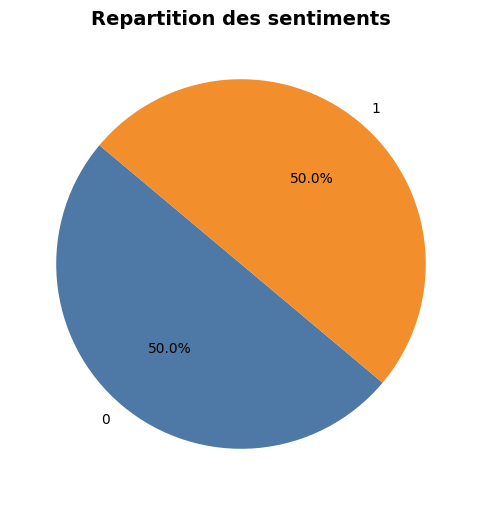

artifact_uri: file:///home/ulrichsama/mlflow_project/mlruns/231745430229609696/49eba53c9c294e3391c3317d5e7117ef/artifacts
artifacts: [<FileInfo: file_size=23946, is_dir=False, path='artifacts/bar_chart_pourcentage.jpg'>, <FileInfo: file_size=14634, is_dir=False, path='artifacts/pie_chart_repartition.jpg'>]
[<FileInfo: file_size=23946, is_dir=False, path='artifacts/bar_chart_pourcentage.jpg'>, <FileInfo: file_size=14634, is_dir=False, path='artifacts/pie_chart_repartition.jpg'>]
🏃 View run data_visualisation at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/49eba53c9c294e3391c3317d5e7117ef
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [8]:
print(dataset["target"].describe())
repartition = dataset["target"].value_counts()
repartition_pct = dataset["target"].value_counts(normalize=True) * 100

with mlflow.start_run(run_name="data_visualisation"):

    # ==================================================
    # GRAPHIQUE 1 : Le Pie Chart
    # ==================================================
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.pie(
        repartition,
        labels=repartition.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=["#4e79a7", "#f28e2b"]
    )
    ax1.set_title("Repartition des sentiments", fontsize=14, weight="bold")
    mlflow.log_figure(fig1, "pie_chart_repartition.jpg")
    plt.show()
    plt.close(fig1)


    # ==================================================
    # GRAPHIQUE 2 : Le Bar Chart (Histogramme)
    # ==================================================
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    bars = ax2.bar(
        repartition_pct.index,
        repartition_pct.values, 
        color=["#4e79a7", "#f28e2b"]
    )
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",  # Texte à afficher
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),  # Position (x, y)
            xytext=(0, 3),  # Décalage de 3 points vers le haut
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
        )
    ax2.set_title("Répartition en pourcentage des émotions", fontsize=14, weight="bold")
    ax2.set_xlabel("Emotions")
    ax2.set_ylabel("Repartition")

    # Log du deuxième graphique (dans le même dossier 'plots')
    mlflow.log_figure(fig2, "bar_chart_pourcentage.jpg")
    print("artifact_uri:", mlflow.get_artifact_uri())
    print("artifacts:", mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    print(mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    plt.close(fig2)


In [9]:
with mlflow.start_run(run_name="data_statistics"):
    # Logger les statistiques du dataset
    mlflow.log_param("sentiments_0", int(repartition[0]))
    mlflow.log_param("sentiments_1", int(repartition[1]))
    mlflow.log_param("sentiments_0_pct", f"{repartition_pct[0]:.2f}%")
    mlflow.log_param("sentiments_1_pct", f"{repartition_pct[1]:.2f}%")
    mlflow.log_param("total_samples", len(dataset))
    
    print("✓ Statistics logged successfully!")
    print(f"  - Sentiment 0: {repartition[0]} samples ({repartition_pct[0]:.2f}%)")
    print(f"  - Sentiment 1: {repartition[1]} samples ({repartition_pct[1]:.2f}%)")

✓ Statistics logged successfully!
  - Sentiment 0: 800000 samples (50.00%)
  - Sentiment 1: 800000 samples (50.00%)
🏃 View run data_statistics at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/33f4f3eba1624a359ec7df3089816200
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [10]:
SAMPLING_RATIO = 0.02
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(dataset["text"], dataset["target"], train_size=SAMPLING_RATIO, stratify=dataset["target"], random_state=RANDOM_STATE)

repartition = y_train.value_counts()
repartition_pct = y_train.value_counts(normalize=True) * 100
print(repartition)
with mlflow.start_run(run_name="data_sampling"):
    mlflow.log_param("RANDOM_STATE", RANDOM_STATE)
    mlflow.log_param("SAMPLING_RATIO", SAMPLING_RATIO)
    

target
0    16000
1    16000
Name: count, dtype: int64
🏃 View run data_sampling at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/4d40ece5dc5248319a4ab8255b128ab3
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [11]:
# Dictionnaire des emojis - À compléter selon vos besoins
with open('dict_emojis.json', 'r', encoding='utf-8') as fichier:
    # Transforme le contenu du fichier JSON en dictionnaire Python
    dict_emojis = json.load(fichier)

try:
    with open('stopwords.txt', 'r', encoding='utf-8') as fichier:
        stopwords = set(ligne.strip() for ligne in fichier if ligne.strip())
        
    print(f"{len(stopwords)} stopwords chargés avec succès !")
except FileNotFoundError:
    print("Erreur : Le fichier 'stopwords.txt' est introuvable.")

423 stopwords chargés avec succès !


In [12]:
try:
    nlp_models = {
        "fr": spacy.load("fr_core_news_sm"),
        "en": spacy.load("en_core_web_sm")
    }
    
except OSError:
    print("Erreur : Le modèle SpaCy n'est pas installé. Lancez : python -m spacy download fr_core_news_sm")

stemmers = {
    "fr": SnowballStemmer("french"),
    "en": SnowballStemmer("english")
}

def preprocess_text(tweet, stem_or_lem="lem"):
    if isinstance(tweet, list):
        tweet = " ".join(str(element) for element in tweet)
        
    # On force la conversion en texte (pour éviter les crashs si une ligne est vide/NaN)
    tweet = str(tweet)
    try:
        langue_detectee = detect(tweet)
    except LangDetectException:
        langue_detectee = "en" # Valeur par défaut si le texte est vide ou indétectable
        
    # Si la langue n'est ni anglais ni français, on force l'anglais par défaut
    if langue_detectee not in ["fr", "en"]:
        langue_detectee = "en"

    texte = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    texte = re.sub(r'@\w+', '', texte)
    texte = re.sub(r'#\w+', '', texte)
    texte = emoji.demojize(texte, language=langue_detectee)
    for emoticon, valeur_texte in dict_emojis[langue_detectee].items():
        texte = texte.replace(emoticon, f" {valeur_texte} ")
    texte = re.sub(r'\s+', ' ', texte).strip()

    doc = nlp_models[langue_detectee](texte)
    mots =[]
    for token in doc:
        if token.is_punct or token.is_space:
            continue  
        mot_original = token.text.lower()
        if stem_or_lem == "lem":
            mot_transforme = token.lemma_.lower()
        elif stem_or_lem == "stem":
            mot_transforme = stemmers[langue_detectee].stem(mot_original)
            
        if mot_original not in stopwords and mot_transforme not in stopwords:
            mots.append(mot_transforme)
    return mots
    

# Test et logging dans MLflow
with mlflow.start_run(run_name="text_preprocessing"):
    example_text = "This is a sample tweet with @user and http://example.com :) !!!"
    processed = preprocess_text(example_text)
    print(f"Original: {example_text}")
    print(f"Processed: {processed}")
    

Original: This is a sample tweet with @user and http://example.com :) !!!
Processed: ['sample', 'tweet', 'smile']
🏃 View run text_preprocessing at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/be6ffccf72d446268dff820d34786f61
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [13]:
# Division train/test stratifiée


X_train1, X_test1, y_train1, y_test1 = train_test_split(X_train, y_train, test_size=0.15, random_state=90, stratify=y_train)
with mlflow.start_run(run_name="data_splitting"):
    repartition = y_train1.value_counts()
    repartition_pct = y_train1.value_counts(normalize=True) * 100
    mlflow.log_param("TEST SIZE", 0.15)
    mlflow.log_param("RANDOM STATE", 90)
    mlflow.log_metric("train_size", len(X_train1))
    mlflow.log_metric("test_size_n", len(X_test1))
    mlflow.log_metric("train_negative_pct", repartition_pct.get(0, 0))
    mlflow.log_metric("train_positive_pct", repartition_pct.get(1, 0))
    print(len(X_test1))
    

4800
🏃 View run data_splitting at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/44c154428bab440189b9c103b07eb5af
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [14]:
X_train1 = X_train1.to_frame(name="text")
X_test1 = X_test1.to_frame(name="text")

texte_traitee_train = [preprocess_text(ligne) for ligne in X_train1["text"]]
texte_traitee_test = [preprocess_text(ligne) for ligne in X_test1["text"]]

X_train1["pretrained"] = texte_traitee_train
X_test1["pretrained"] = texte_traitee_test


In [15]:
textes_finaux_train = [" ".join(lst) for lst in texte_traitee_train]
textes_finaux_test = [" ".join(lst) for lst in texte_traitee_test]
X_train1['final_processed_text'] = textes_finaux_train
X_test1['final_processed_text'] = textes_finaux_test

print(f"✅ {len(X_train1)} textes train / {len(X_test1)} textes test prétraités (colonnes alignées)")
print(X_train1[["text", "final_processed_text"]].head())

✅ 27200 textes train / 4800 textes test prétraités (colonnes alignées)
                                                      text  \
263470   @dmplace Yeah my app has like a 2 1/2 star rat...   
705036                Thiiuu  I think I'm getting ill -.-'   
1237915  Seems like erryone is working on their beach b...   
727630   I will soon requre an rss aggregator for my rs...   
1532176  While going through my purse to find nail clip...   

                                      final_processed_text  
263470                      yeah app 2 1/2 star rating lol  
705036                                          thiiuu ill  
1237915           erryone beach bod guess mine gym partner  
727630          soon requre rss aggregator rss subsciption  
1532176  purse nail clipper hole lining news dig $ 5 ch...  


In [16]:
print(X_train1)

                                                      text  \
263470   @dmplace Yeah my app has like a 2 1/2 star rat...   
705036                Thiiuu  I think I'm getting ill -.-'   
1237915  Seems like erryone is working on their beach b...   
727630   I will soon requre an rss aggregator for my rs...   
1532176  While going through my purse to find nail clip...   
...                                                    ...   
94195    El pollo loco commercials gross me out. I can ...   
433376   #frenchopen Sod loses the firwst game of the t...   
326894   it's only been 46 minutes? UGH. It feels like ...   
1118137  @crackedknuckles lol thts what i thought curti...   
330146     just another night another dream wasted on you    

                                                pretrained  \
263470              [yeah, app, 2, 1/2, star, rating, lol]   
705036                                       [thiiuu, ill]   
1237915   [erryone, beach, bod, guess, mine, gym, partner]   
727630 

In [17]:
with mlflow.start_run(run_name="tfidf_vectorization"):
    min_df = 5
    # CORRECTION : max_df=10000 (entier) ignorait les termes présents dans plus de
    # 10 000 documents sur un corpus de 27 200 (~37%) - probablement pas l'intention.
    # On utilise une proportion, plus lisible et plus standard.
    max_df = 0.8
    stopword = "english"
    tfidf = TfidfVectorizer(
        min_df=min_df, max_df=max_df, stop_words=stopword,
        ngram_range=(1, 2), max_features=5000,
    )
    tfidf.fit(X_train1["final_processed_text"])
    X_train_tfidf = tfidf.transform(X_train1["final_processed_text"])
    X_test_tfidf = tfidf.transform(X_test1["final_processed_text"])

    # SUPPRIMÉ : le scatter PCA qui n'étiquetait que 4 points sur ~4800 et n'était
    # jamais loggé, ainsi que l'export CSV de la matrice TF-IDF complète du test set
    # (4800 x 3578 valeurs) en artefact MLflow - volumineux et peu utile à conserver.

    mlflow.log_params({
        "min_df": min_df,
        "max_df": max_df,  # CORRECTION : la clé était mal orthographiée "mac_df"
        "stop_words": stopword,
        "ngram_range": "(1, 2)",
        "max_features": 5000,
    })
    mlflow.log_metric("Taille_vocabulaire", len(tfidf.vocabulary_))

print(X_train_tfidf.shape)
print(y_train1.shape)
print(X_test_tfidf.shape)
print(y_test1.shape)


🏃 View run tfidf_vectorization at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/c042f73c1caa4d2493d1be184ae67b7c
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
(27200, 4488)
(27200,)
(4800, 4488)
(4800,)


In [24]:
from sklearn.metrics import confusion_matrix, roc_curve

def evaluate_and_log_model(model, model_name, X_train, X_test, y_train, y_test, **model_params):
    with mlflow.start_run(run_name=model_name) as run:
        if model_params:
            model.set_params(**model_params)

        # AJOUT : logging des hyperparamètres (absent de la version précédente,
        # pourtant demandé par l'énoncé)
        try:
            for k, v in model.get_params().items():
                mlflow.log_param(k, v)
        except Exception:
            pass

        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        predictions = model.predict(X_test)
        # LinearRegression renvoie des valeurs continues : on binarise pour les
        # métriques de classification (accuracy, f1, matrice de confusion)
        pred_labels = np.round(np.clip(predictions, 0, 1)).astype(int)

        # CORRECTION : l'AUC doit être calculée sur des scores/probabilités continus,
        # pas sur les labels 0/1 déjà prédits (ce que faisait `roc_auc_score(y_test, predictions)`
        # dans la version précédente - ça fausse complètement la métrique).
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = predictions

        accuracy = accuracy_score(y_test, pred_labels)
        f1 = f1_score(y_test, pred_labels, average="weighted")
        auc = roc_auc_score(y_test, y_score)

        metrics = {
            "Temps_entrainement_secondes": training_time,
            "Accuracy": accuracy,
            "f1_score": f1,
            "AUC_ROC_Score": auc,
        }
        mlflow.log_metrics(metrics)

        # AJOUT : matrice de confusion (demandée par l'énoncé, absente avant)
        cm = confusion_matrix(y_test, pred_labels)
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Négatif", "Positif"], yticklabels=["Négatif", "Positif"], ax=ax_cm)
        ax_cm.set_xlabel("Prédiction")
        ax_cm.set_ylabel("Réalité")
        ax_cm.set_title(f"Matrice de confusion - {model_name}")
        mlflow.log_figure(fig_cm, f"confusion_matrix_{model_name}.png")
        plt.close(fig_cm)

        # AJOUT : courbe ROC (demandée par l'énoncé, absente avant)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        fig_roc, ax_roc = plt.subplots(figsize=(5, 4))
        ax_roc.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey")
        ax_roc.set_xlabel("Taux de faux positifs")
        ax_roc.set_ylabel("Taux de vrais positifs")
        ax_roc.set_title(f"Courbe ROC - {model_name}")
        ax_roc.legend()
        mlflow.log_figure(fig_roc, f"roc_curve_{model_name}.png")
        plt.close(fig_roc)

        model_info = mlflow.sklearn.log_model(model, name=model_name)
        run_id = run.info.run_id

    return {**metrics, "model_uri": model_info.model_uri, "run_id": run_id}


In [25]:
# AJOUT : modèles manquants par rapport à la liste demandée par l'énoncé
# (LinearRegression et DecisionTree n'étaient jamais testés, XGBoost jamais importé)
models_to_compare = {
    "Regression_Logistic": LogisticRegression(max_iter=1000),
    "Regression_Lineaire": LinearRegression(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=10, criterion="entropy", random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(),
}

try:
    from xgboost import XGBClassifier
    models_to_compare["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=42)
except ImportError:
    print("⚠️ xgboost n'est pas installé (pip install xgboost) - modèle ignoré.")

results = {}
for index, value in models_to_compare.items():
    results[index] = evaluate_and_log_model(value, index, X_train_tfidf, X_test_tfidf, y_train1, y_test1)

results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
print("\n🏆 Comparaison des modèles :")
print(results_df[["Accuracy", "AUC_ROC_Score", "f1_score", "Temps_entrainement_secondes"]])


⚠️ xgboost n'est pas installé (pip install xgboost) - modèle ignoré.


2026/07/28 00:50:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Regression_Logistic at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/74c8a5caae3746bd98a1dc9da829225b
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


2026/07/28 00:50:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Regression_Lineaire at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/70ddb1eb675046be9ddf323706be039c
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


...

🏃 View run RandomForestClassifier at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/187b9e5b0b404b24bf13956fdec7e775
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


2026/07/28 00:51:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run DecisionTree at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/9028eec5cf7f4c56838d188ce5f7193c
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


2026/07/28 00:51:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run GradientBoosting at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/1ecb2aab28be426f8619b61b7edb09d3
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696

🏆 Comparaison des modèles :
                        Accuracy AUC_ROC_Score  f1_score  \
Regression_Logistic     0.714583      0.797171  0.713927   
Regression_Lineaire     0.692708      0.770027  0.692221   
RandomForestClassifier      0.68      0.748087  0.679861   
DecisionTree            0.660833      0.669209  0.660267   
GradientBoosting        0.654375      0.731661  0.632898   

                       Temps_entrainement_secondes  
Regression_Logistic                         0.1816  
Regression_Lineaire                       0.126344  
RandomForestClassifier                    4.473042  
DecisionTree                              5.257292  
GradientBoosting                          5.031977  


In [26]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

def log_gridsearch_to_mlflow(estimator, param_grid, X_train, y_train, X_test, y_test, cv=5, scoring='accuracy'):
    with mlflow.start_run(run_name="Optimisation") as parent_run:
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring)
        grid.fit(X_train, y_train)

        cv_results = grid.cv_results_
        nombre_configs = len(cv_results['params'])

        for i in range(nombre_configs):
            with mlflow.start_run(run_name=f"Optimisation_fils{i+1}", nested=True) as child_run:
                mlflow.log_params(cv_results['params'][i])
                mlflow.log_metric(f"cv_mean_{scoring}", cv_results['mean_test_score'][i])
                mlflow.log_metric(f"cv_std_{scoring}", cv_results['std_test_score'][i])
                mlflow.log_metric("fit_time_seconds", cv_results['mean_fit_time'][i])

        best_params = grid.best_params_
        best_model = grid.best_estimator_

        mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
        # On conserve le retour de log_model : model_info.model_uri est la référence
        # FIABLE à utiliser pour l'enregistrement dans le Model Registry (cf. cellule 19)
        model_info = mlflow.sklearn.log_model(best_model, name="meilleur_modele")

        scorer = get_scorer(scoring)
        test_score = scorer(best_model, X_test, y_test)
        mlflow.log_metric(f"test_{scoring}", test_score)

        print("\n✅ Optimisation terminée !")
        print(f"Meilleurs paramètres : {best_params}")
        print(f"Score de validation croisée ({scoring}) : {grid.best_score_:.4f}")
        print(f"Score sur le jeu de test ({scoring}) : {test_score:.4f}")
        return best_model, parent_run.info.run_id, model_info.model_uri

# Configuration de la grille de paramètres
param_grid = {
    'C': [0.1, 1.0, 10.0, 15.0, 20.0],
    'max_iter': [1000, 2000, 3000, 4000, 5000]
}


In [27]:
model_best, id_best_model, best_model_uri = log_gridsearch_to_mlflow(
    models_to_compare["Regression_Logistic"], param_grid,
    X_train_tfidf, y_train1, X_test_tfidf, y_test1, cv=5, scoring='accuracy'
)


🏃 View run Optimisation_fils1 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/72367176f4fb4957be4ace309af1ddcf
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils2 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/d390419d76794504b2c39e5634a0c77e
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils3 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/3d513056c1754744b3497385095cf2f5
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils4 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/ac75e505d0ab4fb28c0a32e2cad7af4d
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils5 at: https://ulrichsama.pyt

2026/07/28 00:52:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ Optimisation terminée !
Meilleurs paramètres : {'C': 1.0, 'max_iter': 1000}
Score de validation croisée (accuracy) : 0.7154
Score sur le jeu de test (accuracy) : 0.7146
🏃 View run Optimisation at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/1d81108e03b448a9bbd79c342bf273a5
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [28]:
model_name = "meilleur_modele"
client = MlflowClient()


model_uri = best_model_uri
model_version_info = mlflow.register_model(model_uri=model_uri, name=model_name)

version = model_version_info.version
version_str = str(version)
print(f"Modèle enregistré sous le nom '{model_name}', version : {version}")

client.update_registered_model(
    name=model_name,
    description="Modèle de classification optimisé pour prédire la catégorie cible."
)

client.set_registered_model_tag(name=model_name, key="tache", value="classification_binaire")
client.set_model_version_tag(name=model_name, version=version_str, key="statut_validation", value="approuve_par_data_scientist")
print("✅ Métadonnées et tags ajoutés.")

print("\n3. Gestion des transitions (Staging -> Production)...")
# NB : on utilise les alias (API moderne) plutôt que transition_model_version_stage,
# qui est dépréciée dans les versions récentes de MLflow.
client.set_registered_model_alias(name=model_name, alias="Staging", version=version_str)
print(f"✅ L'alias 'Staging' a été assigné à la version {version_str}.")

client.set_registered_model_alias(name=model_name, alias="Production", version=version_str)
print(f"✅ L'alias 'Production' a été assigné à la version {version_str}.")


Registered model 'meilleur_modele' already exists. Creating a new version of this model...
2026/07/28 00:53:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: meilleur_modele, version 14
Created version '14' of model 'meilleur_modele'.


Modèle enregistré sous le nom 'meilleur_modele', version : 14
✅ Métadonnées et tags ajoutés.

3. Gestion des transitions (Staging -> Production)...
✅ L'alias 'Staging' a été assigné à la version 14.
✅ L'alias 'Production' a été assigné à la version 14.


1. Analyse globale : Extraction des coefficients...
[-0.61840309  0.26720503  0.78569623 ...  0.52214107  0.8755801
  0.2051442 ]


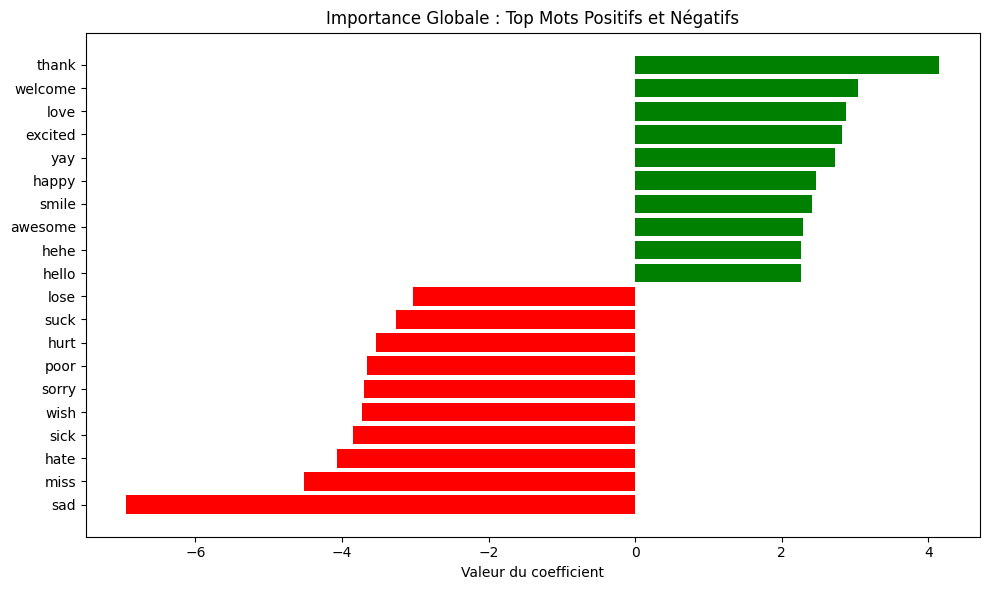

✅ Graphique des coefficients loggé.

2. Analyse locale avec LIME...


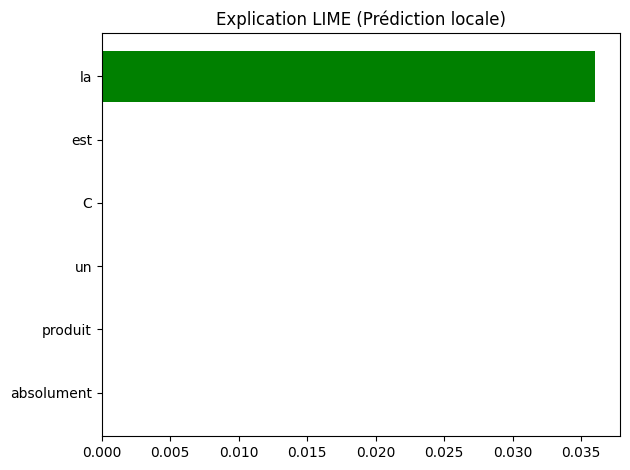

✅ Explications LIME loggées pour l'exemple : 'C'est un produit absolument fantastique mais la livraison a été un peu lente.'
🏃 View run model_interpretability at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/fae8b1a6816a44a5b72b4b4da3bcd8fd
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [29]:
# Note : Assurez-vous d'avoir en mémoire votre 'vectorizer' et votre 'model' entraînés
# Par exemple : model = LogisticRegression(), vectorizer = TfidfVectorizer()

with mlflow.start_run(run_name="model_interpretability"):
    
    print("1. Analyse globale : Extraction des coefficients...")
    # 1. Analysez les coefficients du modèle (si c'est un modèle linéaire)
    if hasattr(model_best, 'coef_'):
        # On récupère le vocabulaire et les poids
        feature_names = tfidf.get_feature_names_out()
        coefs = model_best.coef_[0] # [0] car c'est souvent une classification binaire
        print(coefs)
        # On isole les 10 mots les plus négatifs et les 10 les plus positifs
        top_positive_indices = np.argsort(coefs)[-10:]
        top_negative_indices = np.argsort(coefs)[:10]
        top_indices = np.concatenate([top_negative_indices, top_positive_indices])
        
        # 2. Créez des visualisations des mots les plus importants
        fig_coef, ax = plt.subplots(figsize=(10, 6))
        colors = ['red' if c < 0 else 'green' for c in coefs[top_indices]]
        ax.barh(np.arange(20), coefs[top_indices], color=colors)
        ax.set_yticks(np.arange(20))
        ax.set_yticklabels(feature_names[top_indices])
        plt.title("Importance Globale : Top Mots Positifs et Négatifs")
        plt.xlabel("Valeur du coefficient")
        plt.tight_layout()
        plt.show()
        # 5. Sauvegardez la visualisation dans MLflow
        mlflow.log_figure(fig_coef, "interpretability/global_coefficients.png")
        plt.close(fig_coef)
        print("✅ Graphique des coefficients loggé.")
    else:
        print("Le modèle n'a pas d'attribut 'coef_'. Étape ignorée.")

    print("\n2. Analyse locale avec LIME...")
    # 3. Configurez LIME pour l'interprétation locale
    # LIME a besoin d'avaler du texte brut et de cracher des probabilités.
    # make_pipeline est parfait pour lier le vectoriseur et le modèle en une seule fonction.
    pipeline = make_pipeline(tfidf, model_best)
    
    # Remplacer les noms de classes par vos vraies catégories si besoin
    explainer = LimeTextExplainer(class_names=['Classe_Negative', 'Classe_Positive'])
    
    # 4. Testez sur des exemples personnalisés
    texte_exemple = "C'est un produit absolument fantastique mais la livraison a été un peu lente."
    
    # On génère l'explication (nécessite predict_proba)
    if hasattr(model_best, 'predict_proba'):
        explanation = explainer.explain_instance(
            texte_exemple, 
            pipeline.predict_proba, 
            num_features=6 # Nombre de mots à mettre en avant
        )
        
        # 5. Sauvegardez toutes les visualisations avec mlflow.log_figure()
        # LIME possède une méthode native pour exporter un graphique Matplotlib
        fig_lime = explanation.as_pyplot_figure()
        plt.title("Explication LIME (Prédiction locale)")
        plt.tight_layout()
        mlflow.log_figure(fig_lime, "interpretability/lime_local_explanation.png")
        plt.show()
        plt.close(fig_lime)
        
        # BONUS TRÈS UTILE : Sauvegarder la version HTML interactive de LIME
        html_path = "lime_report.html"
        explanation.save_to_file(html_path)
        mlflow.log_artifact(html_path, "interpretability")
        
        print(f"✅ Explications LIME loggées pour l'exemple : '{texte_exemple}'")
    else:
        print("Le modèle ne supporte pas 'predict_proba'. LIME a besoin de probabilités pour fonctionner.")

In [30]:
# ============================================================
# AJOUT - Question 13 (absente de la version précédente) :
# Synthèse et analyse de toutes les expériences MLflow
# ============================================================
experiment = client.get_experiment_by_name(experiment_name)
all_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.Accuracy DESC"],
)

records = []
for run in all_runs:
    records.append({
        "run_name": run.data.tags.get("mlflow.runName", ""),
        "run_id": run.info.run_id,
        "accuracy": run.data.metrics.get("Accuracy"),
        "auc": run.data.metrics.get("AUC_ROC_Score"),
        "f1_score": run.data.metrics.get("f1_score"),
        "train_time_s": run.data.metrics.get("Temps_entrainement_secondes"),
    })

runs_df = pd.DataFrame(records)
runs_with_accuracy = runs_df.dropna(subset=["accuracy"]).sort_values("accuracy", ascending=False)

print(f"📊 {len(runs_df)} runs trouvés dans l'expérience '{experiment_name}'")
print("\n🏆 Top runs par accuracy :")
print(runs_with_accuracy.head(10))

report_path = "mlflow_experiments_report.csv"
runs_with_accuracy.to_csv(report_path, index=False)

with mlflow.start_run(run_name="experiments_summary"):
    mlflow.log_artifact(report_path)
    mlflow.log_metric("total_runs_analyzed", len(runs_df))
    if not runs_with_accuracy.empty:
        mlflow.log_metric("best_accuracy_found", runs_with_accuracy.iloc[0]["accuracy"])

print(f"\n✅ Rapport sauvegardé : {report_path}")


📊 549 runs trouvés dans l'expérience 'SentimentClassification'

🏆 Top runs par accuracy :
              run_name                            run_id  accuracy       auc  \
0  Regression_Logistic  3beca22ed26148a6a3674bd4ee4d84ee  0.715000  0.715000   
1  Regression_Logistic  966959f837b74d66ab485296d183c304  0.714792  0.714792   
2  Regression_Logistic  74c8a5caae3746bd98a1dc9da829225b  0.714583  0.797171   
3  Regression_Logistic  3984ac3aadac469e8f4ea63092f07408  0.714583  0.714583   
4  Regression_Logistic  fde70f1accad4711929a28e22960879e  0.714583  0.714583   
5  Regression_Logistic  b9259a4523df4d0da59f320744dc7eeb  0.714583  0.714583   
6   LogisticRegression  e455afc812e34ef0bf828d2062d57319  0.714583  0.714583   
7   LogisticRegression  c4db91a3d6ae4db891313427bbfe0d06  0.714375  0.714375   
8  Regression_Logistic  4dbe77994fa04d23a28e7a4244733ae8  0.714167  0.714167   
9  Regression_Logistic  a85b27a60e1847d1b6e3519355f03185  0.714167  0.714167   

   f1_score  train_time_s  
0

In [31]:
# ============================================================
# AJOUT CRITIQUE - Question 15 (totalement absente de la version précédente) :
# Export des objets nécessaires pour l'API de production (TP suivant)
# Sans cette étape, il n'y a AUCUN fichier .joblib à charger dans l'API FastAPI.
# ============================================================
import joblib
import json
from datetime import datetime

api_artifacts_dir = "api_artifacts"
os.makedirs(api_artifacts_dir, exist_ok=True)

with mlflow.start_run(run_name="deployment_artifacts_export"):

    model_path = os.path.join(api_artifacts_dir, "sentiment_model.joblib")
    vectorizer_path = os.path.join(api_artifacts_dir, "tfidf_vectorizer.joblib")
    preprocessing_path = os.path.join(api_artifacts_dir, "preprocessing_objects.joblib")

    # On exporte le modèle optimisé par GridSearch (model_best) et le vectoriseur TF-IDF (tfidf)
    joblib.dump(model_best, model_path)
    joblib.dump(tfidf, vectorizer_path)

    # NB : les modèles spaCy (nlp_models) ne sont PAS sérialisés ici : trop volumineux
    # et fragiles à transporter en joblib d'un environnement à l'autre. L'API devra
    # faire spacy.load("en_core_web_sm") / spacy.load("fr_core_news_sm") elle-même.
    # On exporte seulement les ressources "légères" du preprocessing.
    joblib.dump({"dict_emojis": dict_emojis, "stopwords": list(stopwords)}, preprocessing_path)

    metadata = {
        "model_name": model_name,
        "algorithm": "LogisticRegression (optimisé GridSearchCV)",
        "training_date": datetime.now().isoformat(),
        "dataset": "Sentiment140",
        "sampling_ratio": SAMPLING_RATIO,
        "vocabulary_size": len(tfidf.vocabulary_),
        "labels": {"0": "negative", "1": "positive"},
    }
    metadata_path = os.path.join(api_artifacts_dir, "model_metadata.json")
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    mlflow.log_param("deployment_strategy", "hybrid_mlflow_joblib")
    mlflow.log_artifacts(api_artifacts_dir, artifact_path="api_artifacts")

    # Test de rechargement (validation que les fichiers sont exploitables tels quels)
    reloaded_model = joblib.load(model_path)
    reloaded_vectorizer = joblib.load(vectorizer_path)
    test_vect = reloaded_vectorizer.transform(["i really love this new feature"])
    test_pred = reloaded_model.predict(test_vect)[0]
    print(f"🧪 Test de rechargement -> sentiment prédit : {'positive' if test_pred == 1 else 'negative'}")

print(f"\n✅ Dossier '{api_artifacts_dir}' créé avec :")
print("   sentiment_model.joblib, tfidf_vectorizer.joblib, preprocessing_objects.joblib, model_metadata.json")


🧪 Test de rechargement -> sentiment prédit : positive
🏃 View run deployment_artifacts_export at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/808841025b6f44ef98f8fa4f7cc127d7
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696

✅ Dossier 'api_artifacts' créé avec :
   sentiment_model.joblib, tfidf_vectorizer.joblib, preprocessing_objects.joblib, model_metadata.json


In [33]:
# ============================================================
# AJOUT - Question 14 (absente de la version précédente) :
# Comparaison des stratégies de chargement MLflow vs Joblib
# (placée après l'export car elle a besoin des fichiers api_artifacts/)
# ============================================================
import mlflow.pyfunc

def load_model_from_mlflow():
    return mlflow.pyfunc.load_model(f"models:/{model_name}@Production")

def load_model_from_joblib():
    m = joblib.load("api_artifacts/sentiment_model.joblib")
    v = joblib.load("api_artifacts/tfidf_vectorizer.joblib")
    return m, v

def benchmark_approaches():
    test_texts = ["I love this product!", "This is terrible.", "Average, nothing special."]

    mlflow_model = load_model_from_mlflow()
    start = time.time()
    for t in test_texts:
        mlflow_model.predict(tfidf.transform([t]))
    mlflow_time = (time.time() - start) / len(test_texts)

    model, vectorizer = load_model_from_joblib()
    start = time.time()
    for t in test_texts:
        model.predict(vectorizer.transform([t]))
    joblib_time = (time.time() - start) / len(test_texts)

    print(f"MLflow : {mlflow_time*1000:.1f} ms/prédiction")
    print(f"Joblib : {joblib_time*1000:.1f} ms/prédiction")
    print(f"🚀 Joblib est {mlflow_time/joblib_time:.1f}x plus rapide")

benchmark_approaches()


MLflow : 0.5 ms/prédiction
Joblib : 0.3 ms/prédiction
🚀 Joblib est 1.5x plus rapide
